In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
from find_best_K import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f

# Example Notebook

This Jupyter notebook illustrates the usage of the Randomized Hierarchical Clustering code.
It is organized into three sections:

- Fitting randomized hierarchical clustering
 - Computing p-value for a given merge
  - estimating the number of clusters using the alpha spending algorithm.

 

# 1. Fitting randomized hierarchical clustering


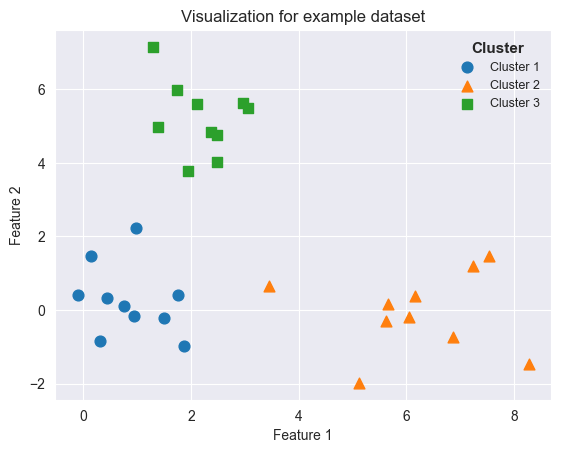

In [2]:
# generate an example dataset with 3 clusters
X, y = generate_data_barbers(10, 6, 1, n_clusters=3, rng=np.random.RandomState(0))
labels = np.unique(y)

markers = ["o", "^", "s", "D", "v", "P", "X"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

plt.figure()
for j, lab in enumerate(labels):
    idx = y == lab
    plt.scatter(
        X[idx, 0], X[idx, 1],
        s=60,
        marker=markers[j],
        color=colors[j],
        label=f"Cluster {int(lab)}"
    )



plt.title("Visualization for example dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

legend = plt.legend(
    title="Cluster",
    loc="upper right",
    fontsize=9,
    title_fontsize=11,
    frameon=False
)
legend.get_title().set_fontweight("bold")

plt.show()

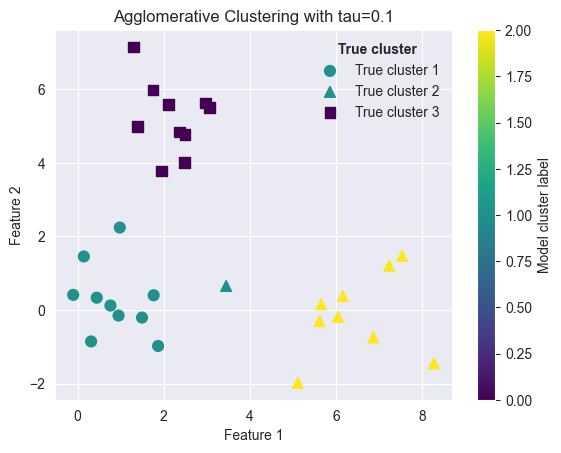

In [3]:
# Non-randomized clustering using our function
model = AgglomerativeClustering(X, tau=0.1, n_clusters=3,linkage="complete",random_state=48)
model.fit(dendrogram=True) # To draw dendrogram, have to set dendrogram = True
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx

markers = ["o", "^", "s"]
true_labels = np.unique(y)

vmin = cluster_labels.min()
vmax = cluster_labels.max()

plt.figure()
for j, lab in enumerate(true_labels):
    idx = (y == lab)
    sc = plt.scatter(
        X[idx, 0], X[idx, 1],
        s=60,
        marker=markers[j],         
        c=cluster_labels[idx],   
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        label=f"True cluster {int(lab)}"
    )

plt.title("Agglomerative Clustering with tau=0.1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

legend = plt.legend(title="True cluster", frameon=False)
legend.get_title().set_fontweight("bold")

cbar = plt.colorbar(sc)
cbar.set_label("Model cluster label")


plt.show()


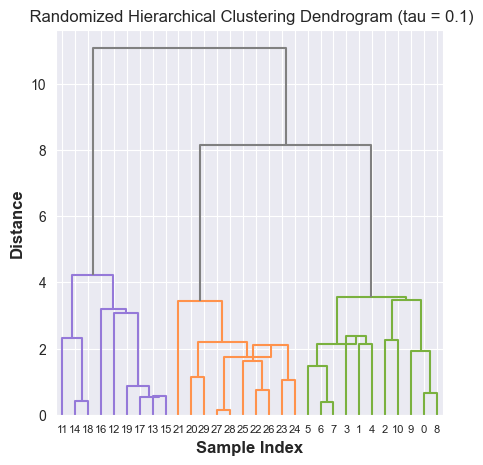

In [4]:
model.plot_dendrogram(manual_color=True)

## 2. Computing p-value for a given merge

### Example a)
Using previous example that has 3 true clusters and fit the model to get 3 clusters

In [5]:
# to get the merges occurred to find the target test that want to test
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1] #test for last merge for example
node = key[0].parent
p_value, obs_target, _ = model.merge_inference_F_grid(node, grid_width=180, ncoarse=20,ngrid=2000)
print("p-value computed",p_value)
print("observed statistics",obs_target)

p-value computed 0.8142051280717796
observed statistics 2.662441736984598


p-value > 0.05, fail to reject the null.

### Example (b)
Using previous example that has 3 true clusters and fit the model to get 2 clusters

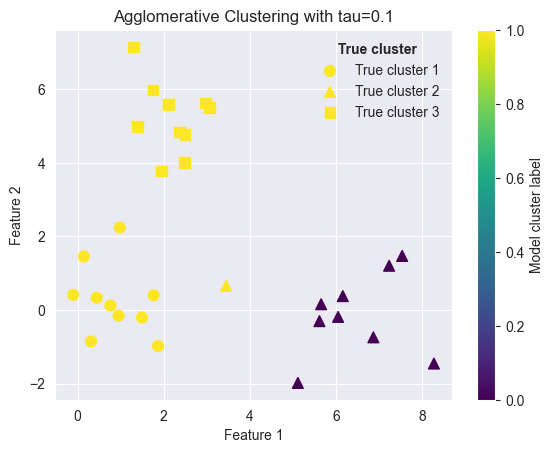

In [6]:
model2 = AgglomerativeClustering(X, tau=0.1, n_clusters=2,linkage="complete",random_state=48)
model2.fit(dendrogram=True) # To draw dendrogram, have to set dendrogram = True
cluster_labels2 = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model2.K_clusters):
    for point_index in node.points:
        cluster_labels2[point_index] = idx

markers = ["o", "^", "s"]
true_labels = np.unique(y)

vmin = cluster_labels2.min()
vmax = cluster_labels2.max()

plt.figure()
for j, lab in enumerate(true_labels):
    idx = (y == lab)
    sc = plt.scatter(
        X[idx, 0], X[idx, 1],
        s=60,
        marker=markers[j],         
        c=cluster_labels2[idx],   
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        label=f"True cluster {int(lab)}"
    )

plt.title("Agglomerative Clustering with tau=0.1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

legend = plt.legend(title="True cluster", frameon=False)
legend.get_title().set_fontweight("bold")

cbar = plt.colorbar(sc)
cbar.set_label("Model cluster label")


plt.show()


In [7]:
# to get the merges occurred to find the target test that want to test
winning_nodes = list(model2.existing_clusters_log.keys())
key = winning_nodes[-1] #test for last merge for example
node = key[0].parent
p_value, obs_target, _ = model2.merge_inference_F_grid(node, grid_width=180, ncoarse=20,ngrid=2000)
print("p-value computed",p_value)
print("observed statistics",obs_target)

p-value computed 0.00020956199258755258
observed statistics 81.49671609710303


p-value < 0.05 for the last merge which indicates that this merge is spurious.

## 3. Alpha-spending algorithm

In [8]:
n = X.shape[0]
alpha_list = generate_alpha_list_exp(n, 0.05, decay_rate=0.3)
K_hat, p_values, alpha_seq, _ = find_best_K_F(X, tau=0.1, alpha_list=alpha_list,
                                              total_alpha=0.05, n_threshold=0.3*n, hard_threshold=0.1*n, seed=int(1000))
# n_threshold is the alpha-spending threshold cluster size
# hard_threshold is the minimum testable cluster size cutoff
print("estimated number of clusters:", K_hat)

estimated number of clusters: 3


The estimated number of clusters here is 3, which matches the true number of cluster K.

We can also run this algorithm several times and estimating the K based on the empirical histogram. Below, we run 50 trials and get the histogram.

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0., 50.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.]),
 array([2.5       , 2.56666667, 2.63333333, 2.7       , 2.76666667,
        2.83333333, 2.9       , 2.96666667, 3.03333333, 3.1       ,
        3.16666667, 3.23333333, 3.3       , 3.36666667, 3.43333333,
        3.5       ]),
 <BarContainer object of 15 artists>)

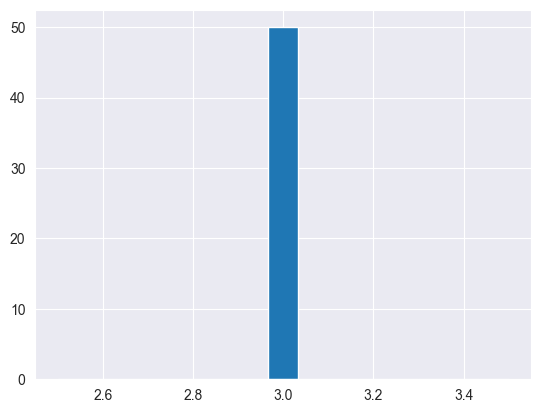

In [9]:
K_hats =[]
for _ in range(50):
    alpha_list = generate_alpha_list_exp(n, 0.05, decay_rate=0.3)
    K_hat, p_values, alpha_seq, _ = find_best_K_F(X, tau=0.1, alpha_list=alpha_list,
                                              total_alpha=0.05, n_threshold=0.3*n, hard_threshold=0.1*n, seed=int(1000))
    K_hats.append(K_hat)


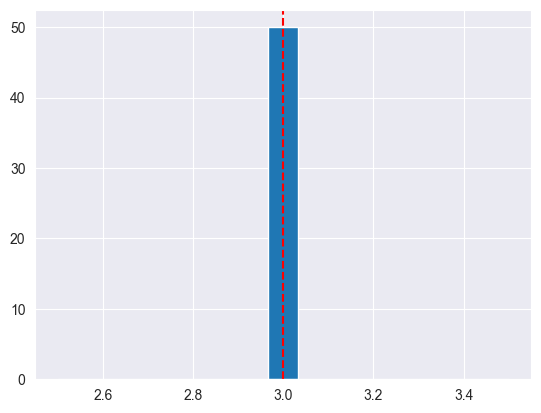

In [10]:
plt.hist(K_hats, bins=15)
plt.axvline(x=3, color='r', linestyle='--')